# BasicViT v3 - ViT-Base with Pretrained Checkpoint
Fine-tune pretrained ViT-Base on HMDB-51, compare with LS-ViT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !pip install -qq torch timm gdown tqdm

# !gdown 141MgG4CC7XffVH32hQy7lQ0PKCafskji
!mkdir -p hmdb51_data
# !unzip -q HMDB51.zip -d hmdb51_data
!unzip -q 'drive/MyDrive/AIVN/AIO-2025/11-12-Video-classification/HMDB51.zip' -d hmdb51_data

In [3]:
from __future__ import annotations
import math
import random
from pathlib import Path
from typing import Optional, Tuple
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.transforms.functional as TF
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Dataset Classes

In [4]:
class VideoTransform:
    """Data augmentation - giống LS-ViT"""
    def __init__(self, mode='train', image_size=224):
        self.is_train = (mode == 'train')
        self.image_size = image_size
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, frames: torch.Tensor) -> torch.Tensor:
        # frames: [T, C, H, W]
        if self.is_train:
            # Random resized crop
            h, w = frames.shape[-2:]
            scale = random.uniform(0.8, 1.0)
            new_h, new_w = int(h * scale), int(w * scale)
            frames = TF.resize(frames, [new_h, new_w], interpolation=transforms.InterpolationMode.BILINEAR)

            # Random crop
            i = random.randint(0, max(0, new_h - self.image_size))
            j = random.randint(0, max(0, new_w - self.image_size))
            frames = TF.crop(frames, i, j, min(self.image_size, new_h), min(self.image_size, new_w))
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

            # Horizontal flip
            if random.random() < 0.5:
                frames = TF.hflip(frames)
        else:
            # Val: center crop
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

        # Normalize
        normalized = [TF.normalize(frame, self.mean, self.std) for frame in frames]
        return torch.stack(normalized)


class HMDB51Dataset(Dataset):
    """Load HMDB51 video frames with grouped train/val split - giống LS-ViT"""
    def __init__(self, root: str, split: str, num_frames: int = 16, frame_stride: int = 1,
                 image_size: int = 224, val_ratio: float = 0.1, seed: int = 42):
        super().__init__()
        self.root = Path(root)
        if not self.root.is_dir():
            raise FileNotFoundError(f"Data root not found: {self.root}")

        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        if not self.classes:
            raise RuntimeError(f"No class folders in {self.root}")
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

        # Group videos by (class, base_video_name)
        grouped_samples: Dict[Tuple[str, str], List[Tuple[List[Path], int]]] = {}
        for cls in self.classes:
            cls_dir = self.root / cls
            for video_dir in sorted([d for d in cls_dir.iterdir() if d.is_dir()]):
                frame_paths = sorted([p for p in video_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
                if not frame_paths:
                    continue
                group_key = (cls, self._base_video_name(video_dir.name))
                grouped_samples.setdefault(group_key, []).append((frame_paths, self.class_to_idx[cls]))

        if not grouped_samples:
            raise RuntimeError(f"No frame folders found inside {self.root}")

        # Split groups (not individual samples)
        group_values = list(grouped_samples.values())
        rng = np.random.RandomState(seed)
        group_indices = np.arange(len(group_values))
        rng.shuffle(group_indices)
        split_point = int(len(group_indices) * (1 - val_ratio))

        if split == "train":
            selected_groups = group_indices[:split_point]
        elif split in ("val", "test"):
            selected_groups = group_indices[split_point:]
        else:
            raise ValueError(f"Unknown split: {split}")

        # Collect samples from selected groups
        samples: List[Tuple[List[Path], int]] = []
        for idx in selected_groups:
            samples.extend(group_values[int(idx)])

        if not samples:
            raise RuntimeError("Selected split has no samples; adjust val_ratio or data folders.")

        self.samples = samples
        self.split = split
        self.num_frames = num_frames
        self.frame_stride = max(1, frame_stride)
        self.transform = VideoTransform(mode='train' if split == 'train' else 'val', image_size=image_size)
        self.to_tensor = transforms.ToTensor()

    def __len__(self) -> int:
        return len(self.samples)

    def _select_indices(self, total: int) -> torch.Tensor:
        """Select frame indices uniformly"""
        if total <= 0:
            raise ValueError("Video folder has no frames")
        if total == 1:
            return torch.zeros(self.num_frames, dtype=torch.long)
        steps = max(self.num_frames * self.frame_stride, self.num_frames)
        grid = torch.linspace(0, total - 1, steps=steps)
        idxs = grid[:: self.frame_stride].long()
        if idxs.numel() < self.num_frames:
            pad = idxs.new_full((self.num_frames - idxs.numel(),), idxs[-1].item())
            idxs = torch.cat([idxs, pad], dim=0)
        return idxs[: self.num_frames]

    @staticmethod
    def _base_video_name(name: str) -> str:
        """Remove trailing _N from video name"""
        match = re.match(r"(.+)_\d+$", name)
        return match.group(1) if match else name

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        frame_paths, label = self.samples[idx]
        total = len(frame_paths)
        idxs = self._select_indices(total)

        frames = []
        for i in idxs:
            path = frame_paths[int(i.item())]
            with Image.open(path) as img:
                img = img.convert("RGB")
                frames.append(self.to_tensor(img))

        video = torch.stack(frames)
        video = self.transform(video)
        return video, label


def collate_fn(batch: List[Tuple[torch.Tensor, int]]) -> Tuple[torch.Tensor, torch.Tensor]:
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return videos, labels

print(" Dataset classes defined (copy from LS-ViT)")


 Dataset classes defined (copy from LS-ViT)


## 2. Load Datasets

In [5]:
DATA_ROOT = './hmdb51_data'
VAL_RATIO = 0.1
SEED = 42
NUM_FRAMES = 16
FRAME_STRIDE = 2
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 4

train_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='train',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)
val_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='val',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

print(f" Train clips: {len(train_dataset)} | Val clips: {len(val_dataset)}")
print(f" Class count: {len(train_dataset.classes)}")

# Show samples
if len(train_dataset) > 0:
    sample_video, sample_label = train_dataset[0]
    print(f"\nTrain sample: {sample_video.shape} - {train_dataset.classes[sample_label]}")

if len(val_dataset) > 0:
    sample_video, sample_label = val_dataset[0]
    print(f"Val sample: {sample_video.shape} - {val_dataset.classes[sample_label]}")


 Train clips: 6121 | Val clips: 645
 Class count: 51

Train sample: torch.Size([16, 3, 224, 224]) - catch
Val sample: torch.Size([16, 3, 224, 224]) - smoke


## 3. Create DataLoaders

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, collate_fn=collate_fn)

print(f" Train batches: {len(train_loader)}")
print(f" Val batches: {len(val_loader)}")

 Train batches: 766
 Val batches: 81


## 4. ViT-Base Architecture (Build from Scratch)

In [7]:
class PatchEmbedding(nn.Module):
    """Convert image to patch embeddings"""
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) -> (B, num_patches, embed_dim)"""
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

print("PatchEmbedding defined")

PatchEmbedding defined


In [8]:
class Attention(nn.Module):
    """Multi-head self-attention"""
    def __init__(self, dim: int, num_heads: int = 12, attn_drop: float = 0.0, proj_drop: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, N, dim) -> (B, N, dim)"""
        B, N, C = x.shape

        # QKV projection
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Apply to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

print("Attention defined")

Attention defined


In [9]:
class Mlp(nn.Module):
    """MLP block"""
    def __init__(self, in_features: int, hidden_features: int = None, out_features: int = None, drop: float = 0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features

        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

print("Mlp defined")

Mlp defined


In [10]:
class TransformerBlock(nn.Module):
    """Transformer block (Attention + MLP)"""
    def __init__(self, dim: int, num_heads: int = 12, mlp_ratio: float = 4.0,
                 drop: float = 0.0, attn_drop: float = 0.0):
        super().__init__()

        # Attention path
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, attn_drop=attn_drop, proj_drop=drop)

        # MLP path
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden, drop=drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Residual attention
        x = x + self.attn(self.norm1(x))
        # Residual MLP
        x = x + self.mlp(self.norm2(x))
        return x

print("TransformerBlock defined")

TransformerBlock defined


In [11]:
class ViTBase(nn.Module):
    """ViT-Base from scratch (vit_base_patch16_224 architecture)

    Specs:
    - Image size: 224
    - Patch size: 16
    - Embed dim: 768
    - Depth: 12
    - Num heads: 12
    - MLP ratio: 4.0
    """

    def __init__(self, image_size: int = 224, patch_size: int = 16, in_channels: int = 3,
                 embed_dim: int = 768, depth: int = 12, num_heads: int = 12,
                 mlp_ratio: float = 4.0, drop_rate: float = 0.0, attn_drop_rate: float = 0.0):
        super().__init__()

        self.embed_dim = embed_dim

        # Patch embedding
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches  # 196 for 224x224, patch_size=16

        # Class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, drop_rate, attn_drop_rate)
            for _ in range(depth)
        ])

        # Layer norm
        self.norm = nn.LayerNorm(embed_dim)

        # Initialize weights
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        """Extract features without classification head"""
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)

        # Add class token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, num_patches+1, embed_dim)

        # Add positional embedding
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Layer norm
        x = self.norm(x)

        return x  # (B, num_patches+1, embed_dim)

print("ViTBase defined")

ViTBase defined


## 5. BasicViT Model

In [12]:
class BasicViT(nn.Module):
    """BasicViT for video classification

    Pipeline:
    1. ViT-Base backbone (from scratch)
    2. Process each frame → extract features
    3. Mean pooling across time (BOTTLENECK!)
    4. Classification head
    """

    def __init__(self, num_classes: int = 51):
        super().__init__()

        # ViT-Base backbone (from scratch, NO pretrained)
        self.vit = ViTBase(
            image_size=224,
            patch_size=16,
            in_channels=3,
            embed_dim=768,
            depth=12,
            num_heads=12,
            mlp_ratio=4.0,
            drop_rate=0.0,
            attn_drop_rate=0.0
        )

        self.embed_dim = self.vit.embed_dim

        # Classification head
        self.head = nn.Linear(self.embed_dim, num_classes)

    def forward(self, video: torch.Tensor) -> torch.Tensor:
        """
        Input: (B, T, C, H, W)
        Output: (B, num_classes)
        """
        B, T, C, H, W = video.shape

        # Process each frame through ViT
        x = video.reshape(B * T, C, H, W)  # (B*T, C, H, W)
        x = self.vit.forward_features(x)  # (B*T, 197, 768)
        x = x[:, 0]  # Take class token (B*T, 768)

        # Mean pooling across frames (LOSES temporal info!)
        x = x.reshape(B, T, self.embed_dim)  # (B, T, 768)
        x = x.mean(dim=1)  # (B, 768) ← THIS IS THE PROBLEM!

        # Classification
        logits = self.head(x)  # (B, num_classes)
        return logits


# Create model
model = BasicViT(num_classes=len(train_dataset.classes)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"   Model created")
print(f"   Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"   Architecture: ViT-Base from scratch")
print(f"   Status: Untrained (from scratch)")

   Model created
   Total parameters: 85,837,875 (85.84M)
   Architecture: ViT-Base from scratch
   Status: Untrained (from scratch)


In [13]:
# Load pretrained ViT-Base weights từ timm
def load_pretrained_vit_checkpoint(model, device=DEVICE):
    """Load pretrained ViT-Base weights từ timm vào custom ViT model"""

    # Load timm ViT-Base pretrained
    timm_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
    timm_model = timm_model.to(device)
    timm_state = timm_model.state_dict()

    # Map và load weights
    custom_state = model.vit.state_dict()
    pretrained_keys = 0

    for key in custom_state.keys():
        if key in timm_state:
            custom_state[key] = timm_state[key]
            pretrained_keys += 1

    model.vit.load_state_dict(custom_state, strict=False)

    print(f" Loaded pretrained ViT-Base checkpoint from timm")
    print(f"   Keys loaded: {pretrained_keys}/{len(custom_state)}")
    print(f"   Status: Ready for fine-tuning")

    return model


# Load pretrained weights
model = load_pretrained_vit_checkpoint(model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

 Loaded pretrained ViT-Base checkpoint from timm
   Keys loaded: 150/150
   Status: Ready for fine-tuning


In [ ]:
# Verify architecture match with timm
timm_vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
timm_vit = timm_vit.to(DEVICE)
my_vit   = model.vit

# Check output shape
x = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    y_timm = timm_vit.forward_features(x)  # (B, 197, 768) for timm ViT
    y_my   = my_vit.forward_features(x)    # (B, 197, 768)

print(f" Architecture verification:")
print(f"   TimM output shape: {y_timm.shape}")
print(f"   Custom output shape: {y_my.shape}")
print(f"   TimM params: {sum(p.numel() for p in timm_vit.parameters())/1e6:.2f}M")
print(f"   Custom params: {sum(p.numel() for p in my_vit.parameters())/1e6:.2f}M")

# Check output similarity
diff = torch.abs(y_timm - y_my).mean().item()
print(f"   Output difference: {diff:.6f}")
if diff < 0.01:
    print(f"   Outputs match perfectly!")


## 6. Training Setup

In [15]:
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# Train all parameters (NOT frozen!)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Training setup:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Trainable parameters: {trainable_params:,} (ALL params)")
print(f"   Optimizer: Adam")
print(f"   Scheduler: CosineAnnealing")

   Training setup:
   Epochs: 10
   Learning rate: 0.0001
   Trainable parameters: 85,837,875 (ALL params)
   Optimizer: Adam
   Scheduler: CosineAnnealing


## 7. Train Functions

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for videos, labels in pbar:
        videos = videos.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(videos)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f'{total_loss / (pbar.n + 1):.4f}',
                         'acc': f'{correct / total:.4f}'})

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for videos, labels in pbar:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({'loss': f'{total_loss / (pbar.n + 1):.4f}',
                             'acc': f'{correct / total:.4f}'})

    return total_loss / len(loader), correct / total

print(" Train/eval functions defined")

# Denormalize for visualization
def denormalize(frames):
    """frames: (T, C, H, W) normalized"""
    frames = frames.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    frames = frames * std + mean
    return frames.clamp(0, 1)


 Train/eval functions defined


## 8. Training Loop

In [17]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0
best_model_path = 'basicvit_best.pt'

print(f"\n{'='*70}")
print(f"Training BasicViT (from scratch) for {EPOCHS} epochs")
print(f"{'='*70}\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"   Best model saved (acc={best_acc:.4f})")

    scheduler.step()
    print()

print(f"{'='*70}")
print(f" Training complete!")
print(f"Best validation accuracy: {best_acc:.4f}")
print(f"{'='*70}")


Training BasicViT (from scratch) for 10 epochs

Epoch 1/10


Training:   0%|          | 0/766 [00:00<?, ?it/s]

Validating:   0%|          | 0/81 [00:00<?, ?it/s]

  Train: Loss=3.3025, Acc=0.1681
  Val:   Loss=2.8840, Acc=0.2713
   Best model saved (acc=0.2713)

Epoch 2/10


Training:   0%|          | 0/766 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/81 [00:00<?, ?it/s]

  Train: Loss=0.0647, Acc=0.9815
  Val:   Loss=2.6621, Acc=0.5333
   Best model saved (acc=0.5333)

Epoch 10/10


Training:   0%|          | 0/766 [00:00<?, ?it/s]

Validating:   0%|          | 0/81 [00:00<?, ?it/s]

  Train: Loss=0.0390, Acc=0.9895
  Val:   Loss=2.6450, Acc=0.5380
   Best model saved (acc=0.5380)

 Training complete!
Best validation accuracy: 0.5380


## 9. Plot Results

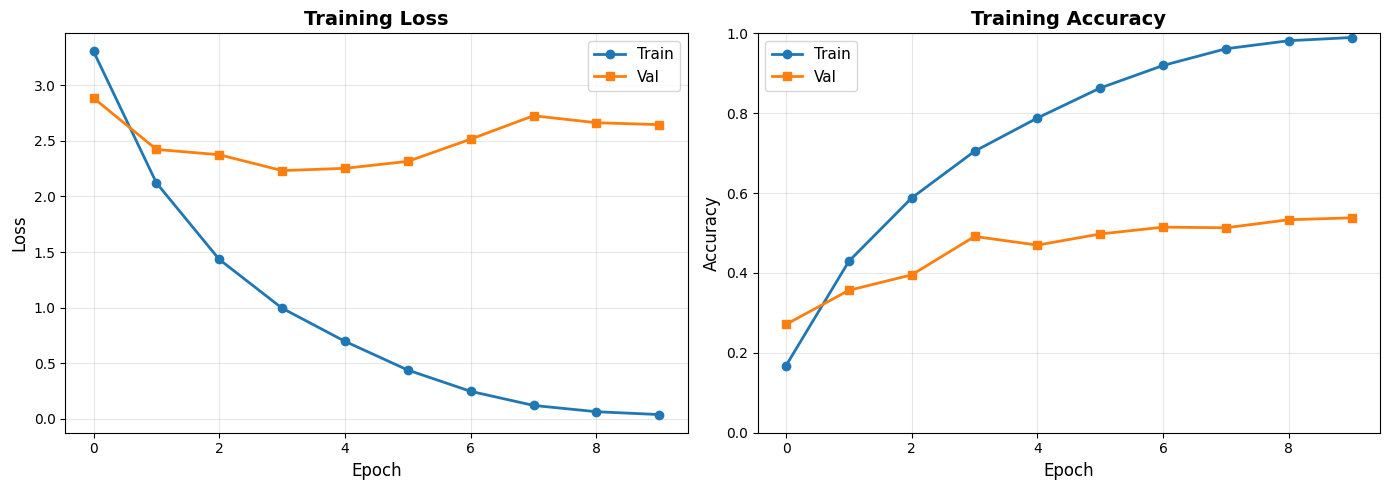

 Plot saved: basicvit_training.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('basicvit_training.png', dpi=100, bbox_inches='tight')
plt.show()

print(" Plot saved: basicvit_training.png")

## 10. Inference

 Best model loaded

Batch Predictions:
Sample   Pred Class           Confidence   GT                   Result
----------------------------------------------------------------------
  0       smoke                0.9959       smoke                YES
  1       smoke                0.9916       smoke                YES
  2       talk                 0.7679       smile                NO


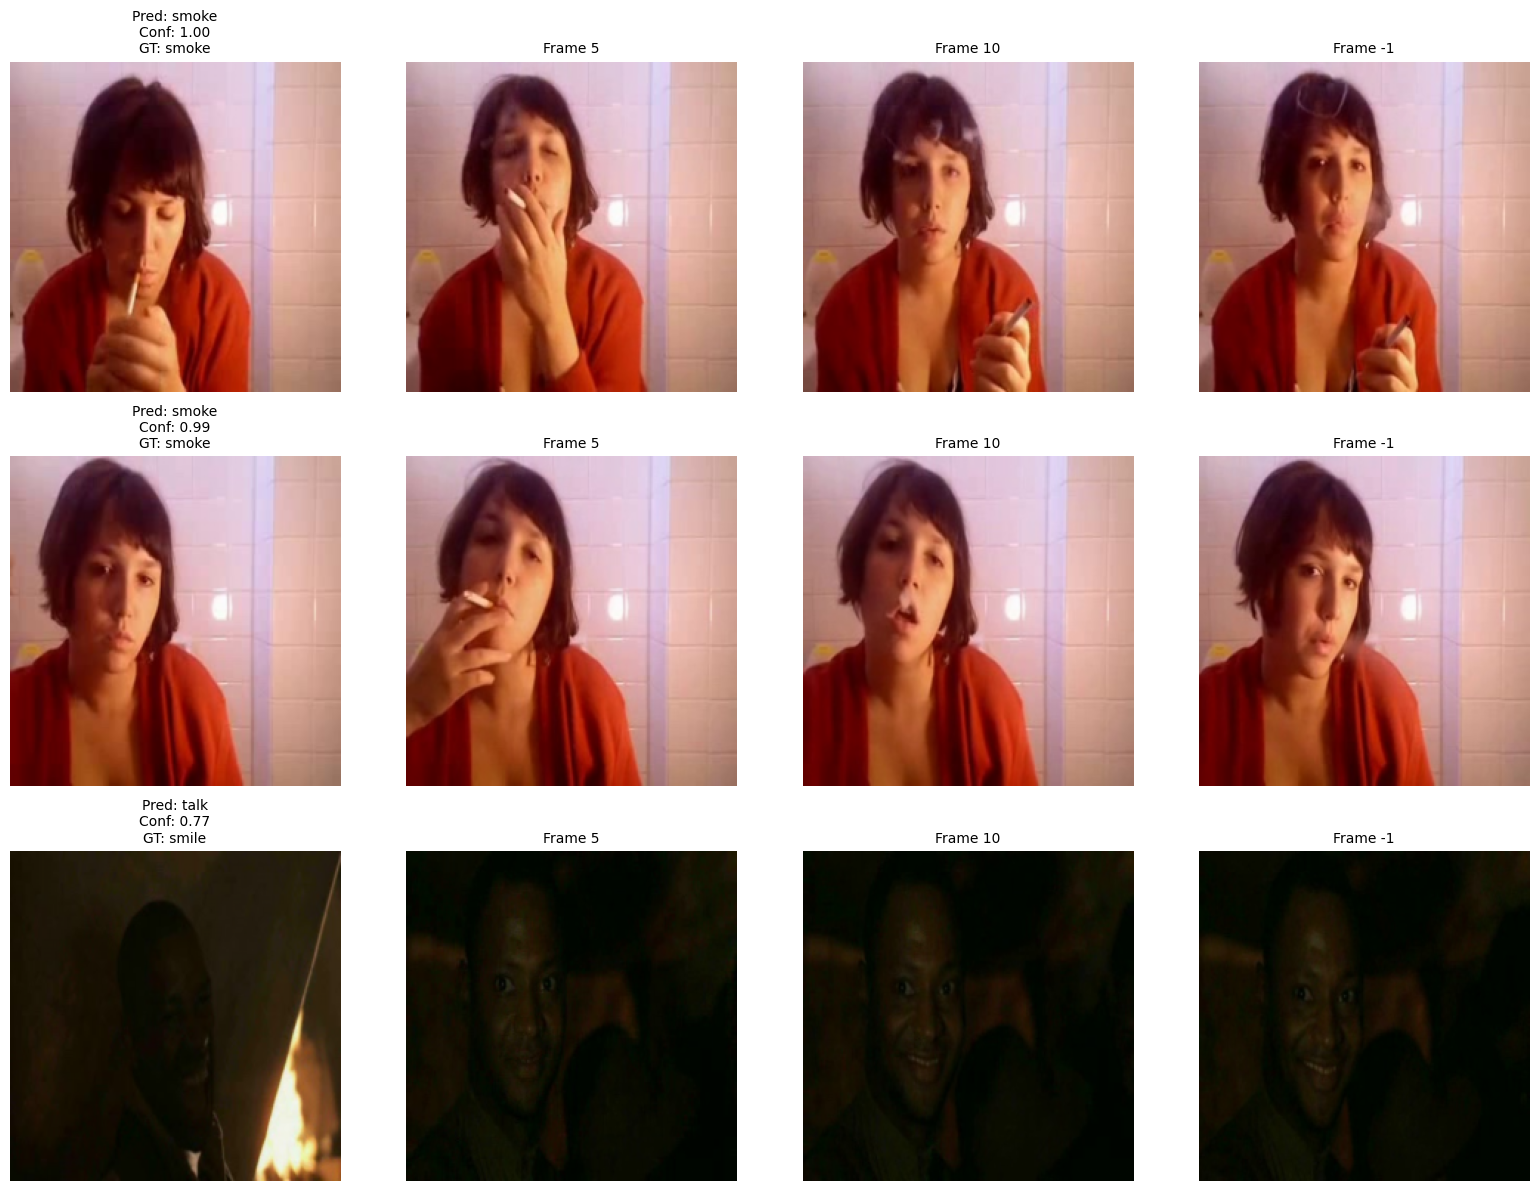


 Visualization saved: inference_results.png


In [19]:
# Load best model
best_model = BasicViT(num_classes=len(train_dataset.classes)).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

print(" Best model loaded\n")

# Predict on validation samples with visualization
with torch.no_grad():
    for videos, labels in val_loader:
        videos_gpu = videos.to(DEVICE)
        outputs = best_model(videos_gpu)
        probs = torch.softmax(outputs, dim=1)

        print(f"Batch Predictions:")
        print(f"{'Sample':<8} {'Pred Class':<20} {'Confidence':<12} {'GT':<20} {'Result'}")
        print("-" * 70)

        # Prepare visualization
        num_samples = min(3, len(labels))
        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            pred = outputs[i].argmax().item()
            conf = probs[i, pred].item()
            gt = labels[i].item()
            match = "YES" if pred == gt else "NO"

            pred_name = train_dataset.classes[pred]
            gt_name = train_dataset.classes[gt]

            print(f"  {i:<7} {pred_name:<20} {conf:<12.4f} {gt_name:<20} {match}")

            # Visualize 4 frames from video
            video = denormalize(videos[i])
            frame_indices = [0, len(video)//3, 2*len(video)//3, -1]

            for j, frame_idx in enumerate(frame_indices):
                frame = video[frame_idx].cpu().numpy().transpose(1, 2, 0)
                axes[i, j].imshow(frame)
                if j == 0:
                    title = f"Pred: {pred_name}\nConf: {conf:.2f}\nGT: {gt_name}"
                else:
                    title = f"Frame {frame_idx}"
                axes[i, j].set_title(title, fontsize=10)
                axes[i, j].axis('off')

        plt.tight_layout()
        plt.savefig('inference_results.png', dpi=100, bbox_inches='tight')
        plt.show()
        print(f"\n Visualization saved: inference_results.png")

        break
